In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
from pandas import ExcelWriter
from pandas import ExcelFile
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches
from functools import reduce
import ast  # To safely evaluate string representations of lists
import glob
from itertools import chain
import inspect
import os

In [2]:
in_df_No = "C:/Users/Lisa/Rezanur/Pytorch/Safety and Security/Kia Soul Aggresive Driving Data/Full_df/Normal/"
in_df_Br = "C:/Users/Lisa/Rezanur/Pytorch/Safety and Security/Kia Soul Aggresive Driving Data/Full_df/Break/"
in_df_Ln = "C:/Users/Lisa/Rezanur/Pytorch/Safety and Security/Kia Soul Aggresive Driving Data/Full_df/Lane/"
in_df_Sp = "C:/Users/Lisa/Rezanur/Pytorch/Safety and Security/Kia Soul Aggresive Driving Data/Full_df/Speed/"

In [3]:
Ali_Lane = pd.read_csv(in_df_Ln + 'Ali Abrupt Lane Change.csv')
Dong_Lane = pd.read_csv(in_df_Ln + 'Donghyun_Lane_Change_2.csv')
Kam_Lane = pd.read_csv(in_df_Ln + 'Kamroon Abrupt Lane Change.csv')
Keun_Lane = pd.read_csv(in_df_Ln + 'Keunyoung_Lane_Change.csv')
Myo_Lane = pd.read_csv(in_df_Ln + 'Myongsu_Lane_Changeing.csv')
New_Lane = pd.read_csv(in_df_Ln + 'New Abrupt Lane Change.csv')
Omar_Lane = pd.read_csv(in_df_Ln + 'Omar Abrupt Lane Change.csv')
Sul_Lane = pd.read_csv(in_df_Ln + 'Sultonbek Abrupt Lane Change.csv')
Yoon_Lane_1 = pd.read_csv(in_df_Ln + 'Yoonji_Lane_Change.csv')
Yoon_Lane_2 = pd.read_csv(in_df_Ln + 'Yoonji_Lane_Change_2.csv')
Yu_Lane_1 = pd.read_csv(in_df_Ln + 'Yujin_Lane_Change.csv')
Yu_Lane_2 = pd.read_csv(in_df_Ln + 'Yujin_Lane_Change_2.csv')
Zoe_Lane = pd.read_csv(in_df_Ln + 'Mrs_Zoe_Lane_Change.csv')

In [4]:
Ali_Nor = pd.read_csv(in_df_No + 'Ali Normal.csv')
City_Nor = pd.read_csv(in_df_No + 'City.csv')
Dong_Nor = pd.read_csv(in_df_No + 'Donghyun_Normal_2.csv')
Kam_Nor = pd.read_csv(in_df_No + 'Kamroon Normal.csv')
Keun_Nor = pd.read_csv(in_df_No + 'Keunyoung_Normal_2.csv')
Myo_Nor = pd.read_csv(in_df_No + 'Myongsu_Normal.csv')
New_Nor = pd.read_csv(in_df_No + 'New Driver Normal.csv')
Omar_Nor = pd.read_csv(in_df_No + 'Omar Normal.csv')
Sul_Nor = pd.read_csv(in_df_No + 'Sultonbek Normal.csv')
Yoon_Nor = pd.read_csv(in_df_No + 'Yoonji_Normal_Driving_2.csv')
Yu_Nor = pd.read_csv(in_df_No + 'Yujin_Normal.csv')
Zoe_Nor = pd.read_csv(in_df_No + 'Mrs_Zoe_Normal.csv')

In [5]:
Ali_Nor = Ali_Nor[Ali_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440', '0510'])]


Ali_Lane = Ali_Lane[Ali_Lane['CAN_ID'].isin(['0220', '0316', '043F', '0440', '0510'])]

In [6]:
def find_values_not_in_a(df1, df2, can_id, position):
    # Extract unique values based on the provided CAN_ID and column name
    a = np.unique(df1[df1['CAN_ID'] == can_id][position])
    b = np.unique(df2[df2['CAN_ID'] == can_id][position])
    
    # Find values in 'b' that are not in 'a'
    values_not_in_a = list(set(b) - set(a))
    
    # Print the results
    print("Normal: ", a)
    print("Abnormal: ", b)
    
    # Check if values_not_in_a is empty and print in red if it is, otherwise in green
    if not values_not_in_a:
        print("\033[91mNot Available Values: \033[0m", values_not_in_a)  # Red if empty
    else:
        print("\033[92mNot Available Values: \033[0m", values_not_in_a)  # Green otherwise

    return values_not_in_a

In [7]:
def print_variable_name(var):
    # Get the current frame and the outer frame
    frame = inspect.currentframe()
    outer_frame = inspect.getouterframes(frame)[1]
    # Find the variable name by inspecting the local variables of the outer frame
    variable_name = [name for name, value in outer_frame.frame.f_locals.items() if value is var]

    # Define the color codes
    color_mapping = {
        'green': ['Ali_Lane', 'Kam_Lane', 'New_Lane', 'Omar_Lane', 'Sul_Lane'],
        'black': ['Dong_Lane', 'Keun_Lane', 'Myo_Lane'],
        'red': ['Yoon_Lane_1', 'Yoon_Lane_2', 'Yu_Lane_1', 'Yu_Lane_2', 'Zoe_Lane']
    }

    # Print the variable name with the corresponding color
    if variable_name:
        name = variable_name[0]
        color_code = ''
        
        # Determine the color based on the variable name
        if name in color_mapping['green']:
            color_code = '\033[32m'  # Green
        elif name in color_mapping['black']:
            color_code = '\033[30m'  # Black
        elif name in color_mapping['red']:
            color_code = '\033[31m'  # Red
        
        # Print the variable name in bold with the corresponding color and a colon
        print(f"{color_code}\033[1m{name}:\033[0m")

In [8]:
var_nor = [Ali_Nor, City_Nor, Dong_Nor, Kam_Nor, Keun_Nor, Myo_Nor, New_Nor, Omar_Nor, Sul_Nor, Yoon_Nor, Yoon_Nor, Yu_Nor, Yu_Nor, Zoe_Nor]
var_ab = [Ali_Lane, Dong_Lane, Kam_Lane, Keun_Lane, Myo_Lane, New_Lane, Omar_Lane, Sul_Lane, Yoon_Lane_1, Yoon_Lane_2, Yu_Lane_1, Yu_Lane_2, Zoe_Lane]

In [74]:
all_diff_043F_Four_ab = []
for i1, i2 in zip(var_nor, var_ab):
    print_variable_name(i2)
    out = find_values_not_in_a(i1, i2, '0220', 'One')
    all_diff_043F_Four_ab.extend(out)  # Use extend to add all values into one list
    print("\n")

i2:
Normal:  ['00' '01' '02' '03' '04' '05' '06' '07' '08' '09' '0A' '0B' '0C' '0D'
 '0E' '0F' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '1A' '1B'
 '1C' '1D' '1E' '1F' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '2A' '2B' '2C' '2D' '2E' '2F' '30' '31' '32' '33' '35' '36' '37' '39'
 '3A' '3B' '3C' '3D' '3E' '41' '42' '44' '46' '48' '4A' '4E' '4F' '51'
 '52' '54' '56' '57' '58' '59' '5A' '5E' '63' '65' '66' '67' '6A' '6B'
 '6C' '6D' '6E' '6F' '70' '71' '72' '73' '74' '75' '76' '77' '78' '79'
 '7A' '7B' '7C' '7D' '7E' '7F' '80' '81' '82' '83' '84' '85' '86' '87'
 '88' '8B' '8C' '8D' '8E' '8F' '90' '91' '92' '93' '95' '96' '97' '98'
 '99' '9B' '9C' '9D' '9E' '9F' 'A0' 'A1' 'A2' 'A3' 'A4' 'A5' 'A6' 'A7'
 'A8' 'A9' 'AA' 'AB' 'AC' 'AD' 'AE' 'AF' 'B0' 'B1' 'B2' 'B3' 'B4' 'B5'
 'B6' 'B7' 'B8' 'BA' 'BB' 'BC' 'BD' 'BE' 'BF' 'C0' 'C1' 'C2' 'C3' 'C4'
 'C5' 'C6' 'C7' 'C8' 'C9' 'CA' 'CB' 'CC' 'CD' 'CE' 'CF' 'D0' 'D1' 'D2'
 'D3' 'D4' 'D5' 'D6' 'D7' 'D8' 'D9' 'DA' 'DB' 'DC' 'DD' 'DE' 'DF

Normal:  ['00' '01' '02' '03' '04' '05' '06' '07' '08' '09' '0A' '0B' '0C' '0D'
 '0E' '0F' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '1A' '1B'
 '1C' '1D' '1E' '1F' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '2A' '2B' '2C' '2D' '2E' '2F' '30' '31' '32' '33' '34' '35' '36' '37'
 '38' '39' '3A' '3B' '3C' '3D' '3E' '3F' '40' '41' '42' '43' '44' '45'
 '46' '47' '48' '49' '4A' '4B' '4C' '4D' '4E' '4F' '50' '51' '52' '53'
 '54' '55' '56' '57' '58' '59' '5A' '5B' '5C' '5D' '5E' '5F' '60' '61'
 '62' '63' '64' '65' '66' '67' '68' '69' '6A' '6B' '6C' '6D' '6E' '6F'
 '70' '71' '72' '73' '74' '75' '76' '77' '78' '79' '7A' '7B' '7C' '7D'
 '7E' '7F' '80' '81' '82' '83' '84' '85' '86' '87' '88' '89' '8A' '8B'
 '8C' '8D' '8E' '8F' '90' '91' '92' '93' '94' '95' '96' '97' '98' '99'
 '9A' '9B' '9C' '9D' '9E' '9F' 'A0' 'A1' 'A2' 'A3' 'A4' 'A5' 'A6' 'A7'
 'A8' 'A9' 'AA' 'AB' 'AC' 'AD' 'AE' 'AF' 'B0' 'B1' 'B2' 'B3' 'B4' 'B5'
 'B6' 'B7' 'B8' 'B9' 'BA' 'BB' 'BC' 'BD' 'BE' 'BF' 'C0' 'C1' 'C2' 'C

In [84]:
Ali_Break = pd.read_csv(in_df_Br + 'Ali Abrupth Break.csv')
Dong_Break_1 = pd.read_csv(in_df_Br + 'Donghyun_Abrupt_Break.csv')
Dong_Break_2 = pd.read_csv(in_df_Br + 'Donghyun_Abrupt_Break_2.csv')
Kam_Break = pd.read_csv(in_df_Br + 'Kamroon Abrupth Break.csv')
Keun_Break_1 = pd.read_csv(in_df_Br + 'Keunyoung_Abrupt_Break_2.csv')
Keun_Break_2 = pd.read_csv(in_df_Br + 'Keunyoung_Abrupt_Break_3.csv')
Myo_Break = pd.read_csv(in_df_Br + 'Myongsu_Abnormal_Break.csv')
New_Break = pd.read_csv(in_df_Br + 'New Abrupth Break.csv')
Omar_Break = pd.read_csv(in_df_Br + 'Omar Abrupth Break.csv')
Sul_Break = pd.read_csv(in_df_Br + 'Sultonbek Abrupth Break.csv')
Yoon_Break_1 = pd.read_csv(in_df_Br + 'Yoonji_Abrupt_Break_2.csv')
Yu_Break = pd.read_csv(in_df_Br + 'Yujin_Abrupt_Break.csv')
Zoe_Break = pd.read_csv(in_df_Br + 'Mrs_Zoe_Abrupt_break.csv')

In [85]:
var_nor = [Ali_Nor, City_Nor, Dong_Nor, Kam_Nor, Keun_Nor, Myo_Nor, New_Nor, Omar_Nor, Sul_Nor, Yoon_Nor, Yoon_Nor, Yu_Nor, Yu_Nor, Zoe_Nor]
var_ab = [Ali_Break, Dong_Break_1, Dong_Break_2, Kam_Break, Keun_Break_1, Keun_Break_2, Myo_Break, New_Break, Omar_Break, Sul_Break, Yoon_Break_1, Yu_Break, Zoe_Break]

In [96]:
all_diff_043F_Four_ab = []
for i1, i2 in zip(var_nor, var_ab):
    print_variable_name(i2)
    out = find_values_not_in_a(i1, i2, '043F', 'Eight')
    all_diff_043F_Four_ab.extend(out)  # Use extend to add all values into one list
    print("\n")

i2:
Normal:  ['00' '15' '16' '17']
Abnormal:  ['00' '14' '15' '1A' '1C' '1E' '1F' '20' '21' '22' '23' '24' '25' '26'
 '28']
Not Available Values:  ['23', '1E', '22', '21', '14', '28', '1F', '26', '20', '1A', '24', '1C', '25']


i2:
Normal:  ['00']
Abnormal:  ['00']
Not Available Values:  []


i2:
Normal:  ['00']
Abnormal:  ['00']
Not Available Values:  []


i2:
Normal:  ['00']
Abnormal:  ['00' '10' '11' '12' '14' '15' '16' '17' '18' '19' '1A' '1B' '1C' '1E'
 '1F' '20' '21' '22' '23' '24' '25' '26' '28' '29' '2A' '2B']
Not Available Values:  ['17', '19', '22', '23', '18', '2A', '15', '21', '28', '1F', '16', '1A', '20', '24', '1C', '25', '12', '10', '1B', '1E', '14', '2B', '26', '29', '11']


i2:
Normal:  ['00' '16' '17' '18' '19' '1A' '1B' '1C' '1E' '1F' '20' '21' '23']
Abnormal:  ['00' '1C' '1E' '1F' '21' '22' '24' '25']
Not Available Values:  ['24', '25', '22']


i2:
Normal:  ['00']
Abnormal:  ['00']
Not Available Values:  []


i2:
Normal:  ['00']
Abnormal:  ['00' '03' '04' '05' '06' 

In [111]:
Ali_Acc = pd.read_csv(in_df_Sp + 'Ali Over Speed.csv')
Dong_Acc_1 = pd.read_csv(in_df_Sp + 'Donghyun_Over_Speed.csv')
Dong_Acc_2 = pd.read_csv(in_df_Sp + 'Donghyun_Over_Speed_2.csv')
Kam_Acc = pd.read_csv(in_df_Sp + 'Kamroon Over Speed.csv')
Keun_Acc_1 = pd.read_csv(in_df_Sp + 'Keunyoung_Over_Speed.csv')
Myo_Acc = pd.read_csv(in_df_Sp + 'Myongsu_Over_Speed.csv')
New_Acc = pd.read_csv(in_df_Sp + 'New Over Speed.csv')
Omar_Acc = pd.read_csv(in_df_Sp + 'Omar Over Speed.csv')
Sul_Acc = pd.read_csv(in_df_Sp + 'Sultonbek Over Speed.csv')
Yoon_Acc_1 = pd.read_csv(in_df_Sp + 'Yoonji_Over_Speed.csv')
Yu_Acc = pd.read_csv(in_df_Sp + 'Yujin_Over_Speed.csv')
Zoe_Acc = pd.read_csv(in_df_Sp + 'Mrs_Zoe_Over_Speed.csv')

In [112]:
var_nor = [Ali_Nor, City_Nor, Dong_Nor, Kam_Nor, Keun_Nor, Myo_Nor, New_Nor, Omar_Nor, Sul_Nor, Yoon_Nor, Yoon_Nor, Yu_Nor, Yu_Nor, Zoe_Nor]
var_ab = [Ali_Acc, Dong_Acc_1, Dong_Acc_2, Kam_Acc, Keun_Acc_1, Myo_Acc, New_Acc, Omar_Acc, Sul_Acc, Yoon_Acc_1, Yu_Acc, Zoe_Acc]

In [136]:
all_diff_043F_Four_ab = []
for i1, i2 in zip(var_nor, var_ab):
    print_variable_name(i2)
    out = find_values_not_in_a(i1, i2, '0220', 'Eight')
    all_diff_043F_Four_ab.extend(out)  # Use extend to add all values into one list
    print("\n")

i2:
Normal:  ['0D' '0E' '0F' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '1A'
 '1B' '1C' '1D' '1E' '1F']
Abnormal:  ['0E' '0F' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '1A' '1B'
 '1C' '1D']
Not Available Values:  []


i2:
Normal:  ['0A' '0B' '0C' '0D' '0E' '0F' '10' '11' '12' '13' '14']
Abnormal:  ['0F' '10']
Not Available Values:  []


i2:
Normal:  ['0A' '0B' '0C' '0D' '0E' '0F' '10' '11' '12' '13' '14' '15' '16' '17'
 '18' '19']
Abnormal:  ['0F' '10']
Not Available Values:  []


i2:
Normal:  ['0D' '0E' '0F' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '1A'
 '1B' '1C']
Abnormal:  ['0E' '0F' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '1A' '1B'
 '1C' '1D' '1E' '1F']
Not Available Values:  ['1D', '1E', '1F']


i2:
Normal:  ['09' '0A' '0B' '0C' '0D' '0E' '0F' '10' '11' '12' '13' '14' '15']
Abnormal:  ['0F' '10' '11']
Not Available Values:  []


i2:
Normal:  ['0F' '10']
Abnormal:  ['0F' '10']
Not Available Values:  []


i2:
Normal:  ['0D' '0E' '0F' '10' '11' '12'

In [164]:
Ali_Nor = pd.read_csv(in_df_No + 'Ali Normal.csv')
Ali_Nor = Ali_Nor[Ali_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Ali_Nor = Ali_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Ali_Nor['Combined'] = Ali_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

City_Nor = pd.read_csv(in_df_No + 'City.csv')
City_Nor = City_Nor[City_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
City_Nor = City_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
City_Nor['Combined'] = City_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Dong_Nor = pd.read_csv(in_df_No + 'Donghyun_Normal_2.csv')
Dong_Nor = Dong_Nor[Dong_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Dong_Nor = Dong_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Dong_Nor['Combined'] = Dong_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Kam_Nor = pd.read_csv(in_df_No + 'Kamroon Normal.csv')
Kam_Nor = Kam_Nor[Kam_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Kam_Nor = Kam_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Kam_Nor['Combined'] = Kam_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Keun_Nor = pd.read_csv(in_df_No + 'Keunyoung_Normal_2.csv')
Keun_Nor = Keun_Nor[Keun_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Keun_Nor = Keun_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Keun_Nor['Combined'] = Keun_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Myo_Nor = pd.read_csv(in_df_No + 'Myongsu_Normal.csv')
Myo_Nor = Myo_Nor[Myo_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Myo_Nor = Myo_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Myo_Nor['Combined'] = Myo_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

New_Nor = pd.read_csv(in_df_No + 'New Driver Normal.csv')
New_Nor = New_Nor[New_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
New_Nor = New_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
New_Nor['Combined'] = New_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Omar_Nor = pd.read_csv(in_df_No + 'Omar Normal.csv')
Omar_Nor = Omar_Nor[Omar_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Omar_Nor = Omar_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Omar_Nor['Combined'] = Omar_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Sul_Nor = pd.read_csv(in_df_No + 'Sultonbek Normal.csv')
Sul_Nor = Sul_Nor[Sul_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Sul_Nor = Sul_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Sul_Nor['Combined'] = Sul_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Yoon_Nor = pd.read_csv(in_df_No + 'Yoonji_Normal_Driving_2.csv')
Yoon_Nor = Yoon_Nor[Yoon_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Yoon_Nor = Yoon_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Yoon_Nor['Combined'] = Yoon_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Yu_Nor = pd.read_csv(in_df_No + 'Yujin_Normal.csv')
Yu_Nor = Yu_Nor[Yu_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Yu_Nor = Yu_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Yu_Nor['Combined'] = Yu_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

Zoe_Nor = pd.read_csv(in_df_No + 'Mrs_Zoe_Normal.csv')
Zoe_Nor = Zoe_Nor[Zoe_Nor['CAN_ID'].isin(['0220', '0316', '043F', '0440'])]
Zoe_Nor = Zoe_Nor[['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Gap']]
# Combine all the columns into one column
Zoe_Nor['Combined'] = Zoe_Nor[['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight']].apply(lambda row: ''.join(row), axis=1)

In [178]:
Ali_Nor

,CAN_ID,One,Two,Three,Four,Five,Six,Seven,Eight,Time_Gap,Combined
0,043F,01,45,60,FF,89,C8,10,00,NaN,014560FF89C81000
2,0440,FF,41,07,00,FF,DC,10,36,0.2,FF410700FFDC1036
5,0220,FE,2B,3D,24,0C,00,F5,0F,0.2,FE2B3D240C00F50F
7,0316,45,51,48,13,51,30,06,7F,1.9,455148135130067F
22,043F,01,45,60,FF,89,E8,10,00,3.0,014560FF89E81000
...,...,...,...,...,...,...,...,...,...,...,...
218491,0440,FF,63,17,00,FF,F4,15,2E,0.3,FF631700FFF4152E
218499,0316,45,25,F8,15,25,28,19,7F,0.3,4525F8152528197F
218506,0220,12,24,88,2B,8E,30,FF,0F,0.2,1224882B8E30FF0F
218511,043F,03,45,60,FF,89,F0,15,00,0.2,034560FF89F01500


In [179]:
# Convert each string into a list of characters for pattern mining
sequences = [list(combined) for combined in Ali_Nor['Combined']]

# Use PrefixSpan to find frequent sequential patterns
ps = PrefixSpan(sequences)
patterns = ps.frequent(minsup=10)  # Adjust minsup for minimum support

# Display the frequent patterns
print("Frequent sequential patterns:")
for pattern in patterns:
    print(pattern)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)




(44, ['A', '2', '4', '2', '8', 'F'])
(23, ['A', '2', '4', '2', '8', '3'])
(22, ['A', '2', '4', '2', '8', '3', '7'])
(22, ['A', '2', '4', '2', '8', '3', '7', 'F'])
(22, ['A', '2', '4', '2', '8', '3', 'F'])
(19, ['A', '2', '4', '2', '8', '0'])
(112, ['A', '2', '4', '2', '2'])
(23, ['A', '2', '4', '2', '2', '1'])
(15, ['A', '2', '4', '2', '2', '1', '7'])
(14, ['A', '2', '4', '2', '2', '1', '7', 'F'])
(14, ['A', '2', '4', '2', '2', '1', 'F'])
(97, ['A', '2', '4', '2', '2', '7'])
(95, ['A', '2', '4', '2', '2', '7', 'F'])
(101, ['A', '2', '4', '2', '2', 'F'])
(25, ['A', '2', '4', '2', '2', '0'])
(15, ['A', '2', '4', '2', '2', '0', 'F'])
(12, ['A', '2', '4', '2', '2', '0', '7'])
(11, ['A', '2', '4', '2', '2', '0', '7', 'F'])
(14, ['A', '2', '4', '2', '2', '3'])
(13, ['A', '2', '4', '2', '2', '3', '7'])
(13, ['A', '2', '4', '2', '2', '3', '7', 'F'])
(13, ['A', '2', '4', '2', '2', '3', 'F'])
(12, ['A', '2', '4', '2', '2', '4'])
(12, ['A', '2', '4', '2', '2', '4', '7'])
(12, ['A', '2', '4', '2'

In [292]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
from pandas import ExcelWriter
from pandas import ExcelFile
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches
from functools import reduce
import ast  # To safely evaluate string representations of lists
import glob
from itertools import chain
import inspect
import os

In [293]:
in_df_No = "FedModel/AggKia/Normal/"
in_df_Br = "FedModel/AggKia/Break/"
in_df_Ln = "FedModel/AggKia/Lane/"
in_df_Sp = "FedModel/AggKia/Speed/"

in_df_Br_att = "FedModel/SitAttKia/Break/"
in_df_Ln_att = "FedModel/SitAttKia/Lane/"
in_df_Sp_att = "FedModel/SitAttKia/Speed/"

In [314]:
def plot_can_rowwise(
    datasets,
    id_col='CAN_ID',
    id_order=None,
    window=1000,
    figsize=(14, 14),
    linewidth=1.2,
    alpha=0.9,
    marker=None,
    sharex=True
):
    if id_order is None:
        id_order = ['0018', '0220', '0316', '043F', '0440', '0510']

    id_label_map = {
        '0018': 'High Priority',
        '0220': 'Brake',
        '0316': 'RPM',
        '043F': 'Gear',
        '0440': 'Speed',
        '0510': 'Ultrasonic Sensor'
    }

    y_tick_labels = [id_label_map.get(cid, cid) for cid in id_order]
    id_to_y = {cid: i for i, cid in enumerate(id_order)}
    n_panels = len(datasets)

    colors = [
        'tab:green',
        'tab:orange',
        'tab:orange',
        'tab:orange',
        'tab:red',
        'tab:red',
        'tab:red'
    ]

    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=figsize,
        sharex=sharex,
        constrained_layout=True
    )

    if n_panels == 1:
        axes = [axes]

    for i, (ax, (label, df)) in enumerate(zip(axes, datasets)):
        d = df.copy().reset_index(drop=True)

        if d.empty:
            ax.set_title(label, loc='center', fontsize=14, fontweight='bold')
            ax.set_yticks(range(len(id_order)))
            ax.set_yticklabels(y_tick_labels, fontsize=12, fontweight='bold')
            ax.set_ylabel("CAN ID", fontsize=14, fontweight='bold')
            ax.grid(True, axis='y', linestyle='--', linewidth=0.9, alpha=0.6, color='gray')
            ax.grid(True, axis='x', linestyle=':', linewidth=0.8, alpha=0.5, color='gray')
            ax.tick_params(axis='x', labelsize=12)
            ax.tick_params(axis='y', labelsize=12)
            continue

        d = d.iloc[:window].copy()

        try:
            d[id_col] = d[id_col].astype(str).str.upper().str.zfill(4)
        except Exception:
            d[id_col] = d[id_col].apply(lambda x: str(x).upper().zfill(4))

        if not d[id_col].isin(id_order).any():
            try:
                d[id_col] = d[id_col].apply(lambda x: format(int(x), '04X'))
            except Exception:
                pass

        d = d[d[id_col].isin(id_order)].copy()
        d['y'] = d[id_col].map(id_to_y)

        ax.plot(
            d.index,
            d['y'],
            linewidth=linewidth,
            alpha=alpha,
            marker=marker,
            color=colors[i % len(colors)]
        )

        ax.set_title(label, loc='center', fontsize=14, fontweight='bold')
        ax.set_yticks(range(len(id_order)))
        ax.set_yticklabels(y_tick_labels, fontsize=12, fontweight='bold')
        ax.set_ylabel("CAN ID", fontsize=14, fontweight='bold')
        ax.grid(True, axis='y', linestyle='--', linewidth=0.9, alpha=0.6, color='gray')
        ax.grid(True, axis='x', linestyle=':', linewidth=0.8, alpha=0.5, color='gray')

        ax.tick_params(axis='x', labelsize=12, width=1.2)
        ax.tick_params(axis='y', labelsize=12, width=1.2)

        if "Attack" in label:
            ax.set_facecolor("#fff7f7")

    axes[-1].set_xlabel("Index", fontsize=14, fontweight='bold')
    plt.show()

In [317]:
up = 43
Kam_Nor = pd.read_csv(in_df_No + 'Kamroon_AF.csv')[:]

Kam_Lane = pd.read_csv(in_df_Ln + 'Kamroon_Abrupt_Lane.csv')[10000:]
Kam_Break = pd.read_csv(in_df_Br + 'Kamroon_Abrupt_Break.csv')[10000:]
Kam_Acc = pd.read_csv(in_df_Sp + 'Kamroon_Speed.csv')[10000:]

Kam_Break_Att = pd.read_csv(in_df_Br_att + 'Kia_Rep_Break.csv')[10000:]
Kam_Lane_Att = pd.read_csv(in_df_Ln_att + 'Kia_Rep_Lane.csv')[10000:]
Kam_Acc_Att = pd.read_csv(in_df_Sp_att + 'Kia_Rep_Acc.csv')[10000:]

Kam_Nor = Kam_Nor[Kam_Nor['CAN_ID'].isin(['0018', '0220', '0316', '043F', '0440', '0510'])].reset_index(drop=True)[21: 21 + up]

Kam_Lane = Kam_Lane[Kam_Lane['CAN_ID'].isin(['0018','0220', '0316', '043F', '0440', '0510'])].reset_index(drop=True)[35: 35 + up]
Kam_Break = Kam_Break[Kam_Break['CAN_ID'].isin(['0018','0220', '0316', '043F', '0440', '0510'])].reset_index(drop=True)[21: 21 + up]
Kam_Acc = Kam_Acc[Kam_Acc['CAN_ID'].isin(['0018', '0220', '0316', '043F', '0440', '0510'])].reset_index(drop=True)[56: 56 + up]

Kam_Break_Att = Kam_Break_Att[Kam_Break_Att['CAN_ID'].isin(['0018','0220', '0316', '043F', '0440', '0510'])].reset_index(drop=True)[8: 8 + up]
Kam_Lane_Att = Kam_Lane_Att[Kam_Lane_Att['CAN_ID'].isin(['0018','0220', '0316', '043F', '0440', '0510'])].reset_index(drop=True)[20: 20 + up]
Kam_Acc_Att = Kam_Acc_Att[Kam_Acc_Att['CAN_ID'].isin(['0018','0220', '0316', '043F', '0440', '0510'])].reset_index(drop=True)[34: 34 + up]

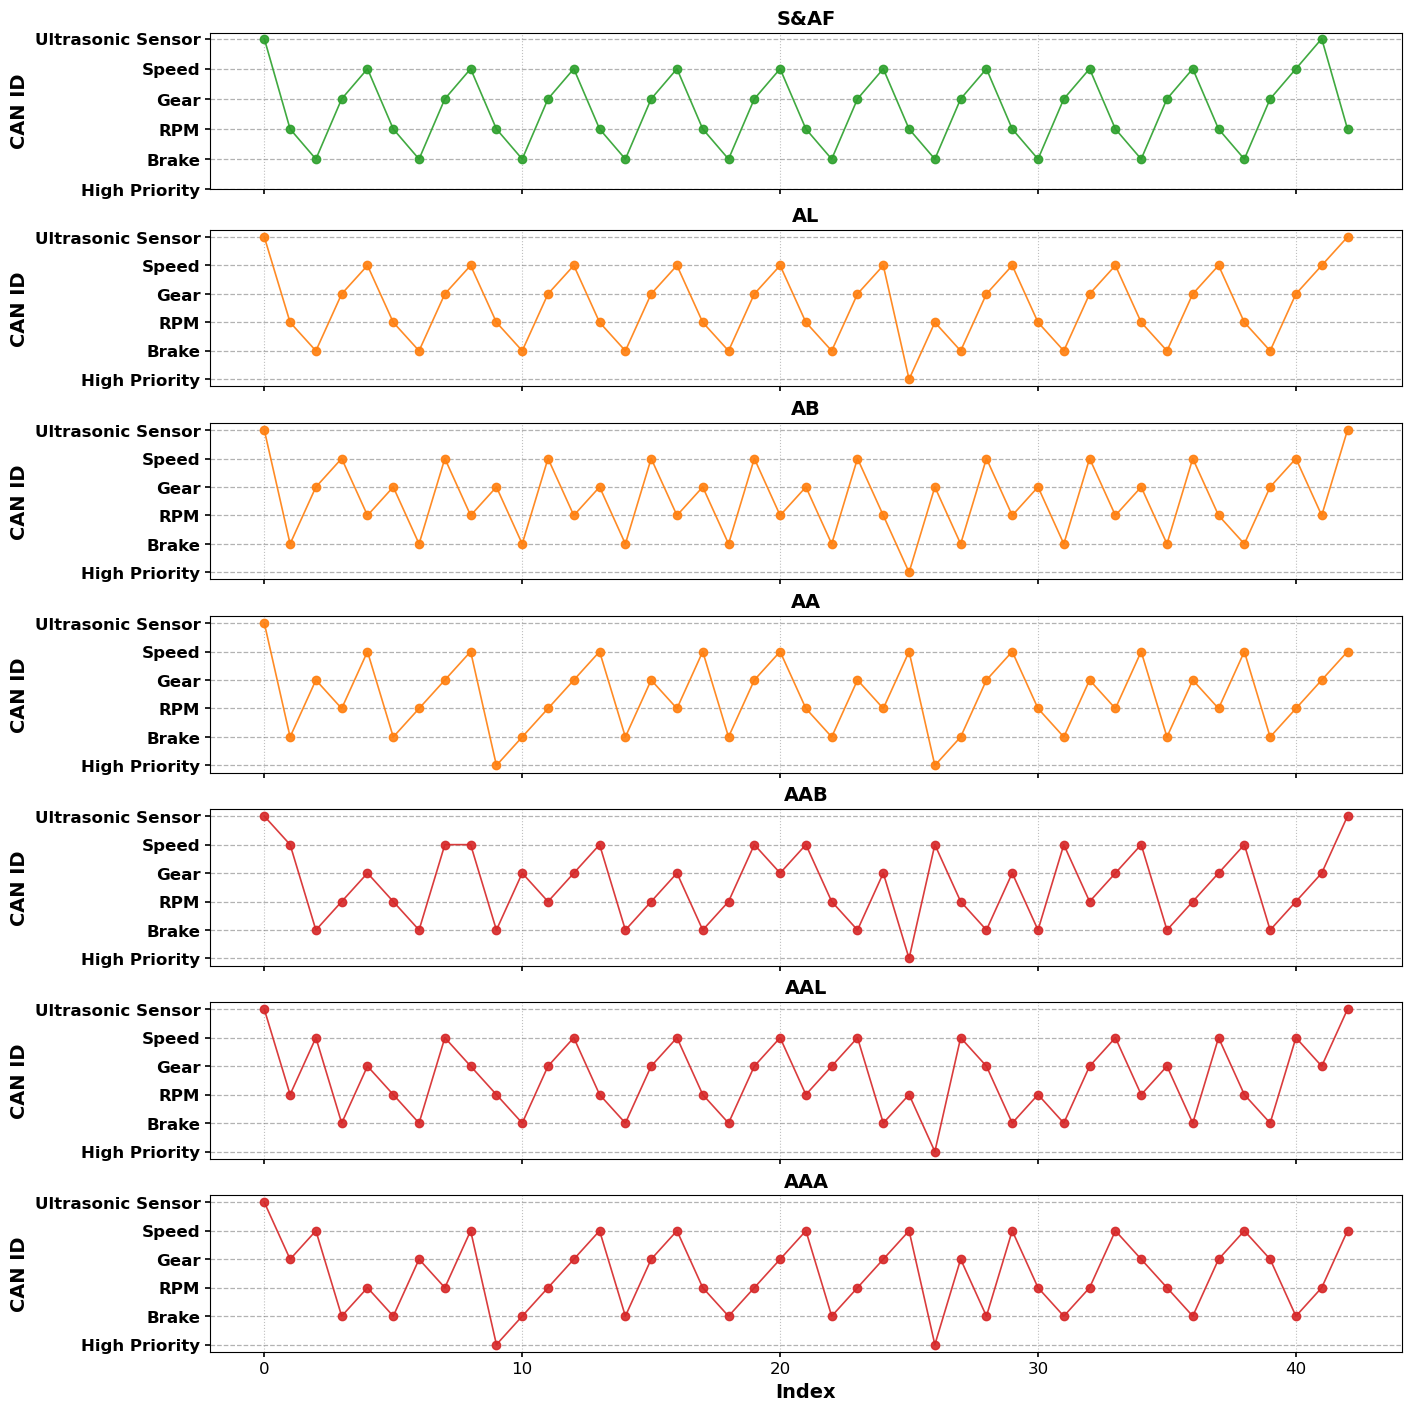

In [322]:
datasets = [
    ("S&AF", Kam_Nor),
    ("AL", Kam_Lane),
    ("AB", Kam_Break),
    ("AA", Kam_Acc),
    ("AAB", Kam_Break_Att),
    ("AAL", Kam_Lane_Att),
    ("AAA", Kam_Acc_Att),
]

plot_can_rowwise(
    datasets,
    id_col='CAN_ID',
    id_order=['0018', '0220', '0316', '043F', '0440', '0510'],
    window=100,
    marker='o'
)

In [319]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator


def plot_can_rowwise_presentable(
    datasets,
    x_col='Time_Delta',
    id_col='CAN_ID',
    id_order=None,
    window=100,
    figsize=(14, 14),
    marker_size=36,
    alpha=0.90,
    sharex=True,
    sort_by_time=True
):
    if id_order is None:
        id_order = ['0018', '0220', '0316', '043F', '0440', '0510']

    # Mapping for display names on y-axis
    id_label_map = {
        '0018': 'High Priority',
        '0220': 'Break',
        '0316': 'RPM',
        '043F': 'Gear',
        '0440': 'Speed',
        '0510': 'Ultrasonic Sensor'
    }

    y_tick_labels = [id_label_map.get(cid, cid) for cid in id_order]
    id_to_y = {cid: i for i, cid in enumerate(id_order)}
    n_panels = len(datasets)

    colors = [
        'tab:green',
        'tab:orange',
        'tab:orange',
        'tab:orange',
        'tab:red',
        'tab:red',
        'tab:red'
    ]

    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=figsize,
        sharex=sharex,
        constrained_layout=True
    )

    if n_panels == 1:
        axes = [axes]

    fig.patch.set_facecolor('white')

    for i, (ax, (label, df)) in enumerate(zip(axes, datasets)):
        d = df.copy().reset_index(drop=True)

        if d.empty:
            ax.set_title(label, loc='center', fontsize=14, fontweight='bold')
            ax.set_yticks(range(len(id_order)))
            ax.set_yticklabels(y_tick_labels, fontsize=12, fontweight='bold')
            ax.set_ylabel("CAN ID", fontsize=14, fontweight='bold')
            ax.grid(True, axis='y', linestyle='--', linewidth=0.9, alpha=0.6, color='gray')
            ax.tick_params(axis='x', labelsize=12, width=1.2)
            ax.tick_params(axis='y', labelsize=12, width=1.2)
            continue

        if x_col not in d.columns:
            raise KeyError(f"Column '{x_col}' not found in dataset '{label}'")

        d = d.iloc[:window].copy()

        try:
            d[id_col] = d[id_col].astype(str).str.upper().str.zfill(4)
        except Exception:
            d[id_col] = d[id_col].apply(lambda x: str(x).upper().zfill(4))

        if not d[id_col].isin(id_order).any():
            try:
                d[id_col] = d[id_col].apply(lambda x: format(int(x), '04X'))
            except Exception:
                pass

        d = d[d[id_col].isin(id_order)].copy()

        if sort_by_time:
            d = d.sort_values(by=x_col).reset_index(drop=True)

        d['y'] = d[id_col].map(id_to_y)

        ax.scatter(
            d[x_col],
            d['y'],
            s=marker_size,
            alpha=alpha,
            color=colors[i % len(colors)],
            edgecolors='none'
        )

        ax.set_title(label, loc='center', fontsize=14, fontweight='bold')
        ax.set_yticks(range(len(id_order)))
        ax.set_yticklabels(y_tick_labels, fontsize=12, fontweight='bold')
        ax.set_ylabel("CAN ID", fontsize=14, fontweight='bold')

        ax.grid(True, axis='y', linestyle='--', linewidth=0.9, alpha=0.6, color='gray')
        ax.grid(True, axis='x', linestyle=':', linewidth=0.8, alpha=0.5, color='gray')
        ax.set_facecolor('white')

        ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

        ax.tick_params(axis='x', labelsize=12, width=1.2)
        ax.tick_params(axis='y', labelsize=12, width=1.2)

        for tick in ax.get_xticklabels():
            tick.set_fontweight('bold')
        for tick in ax.get_yticklabels():
            tick.set_fontweight('bold')

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        if "Attack" in label:
            ax.axhspan(-0.5, len(id_order) - 0.5, color='#fff5f5', zorder=0)

    axes[-1].set_xlabel("Time Gap", fontsize=14, fontweight='bold')

    for tick in axes[-1].get_xticklabels():
        tick.set_fontweight('bold')

    plt.show()

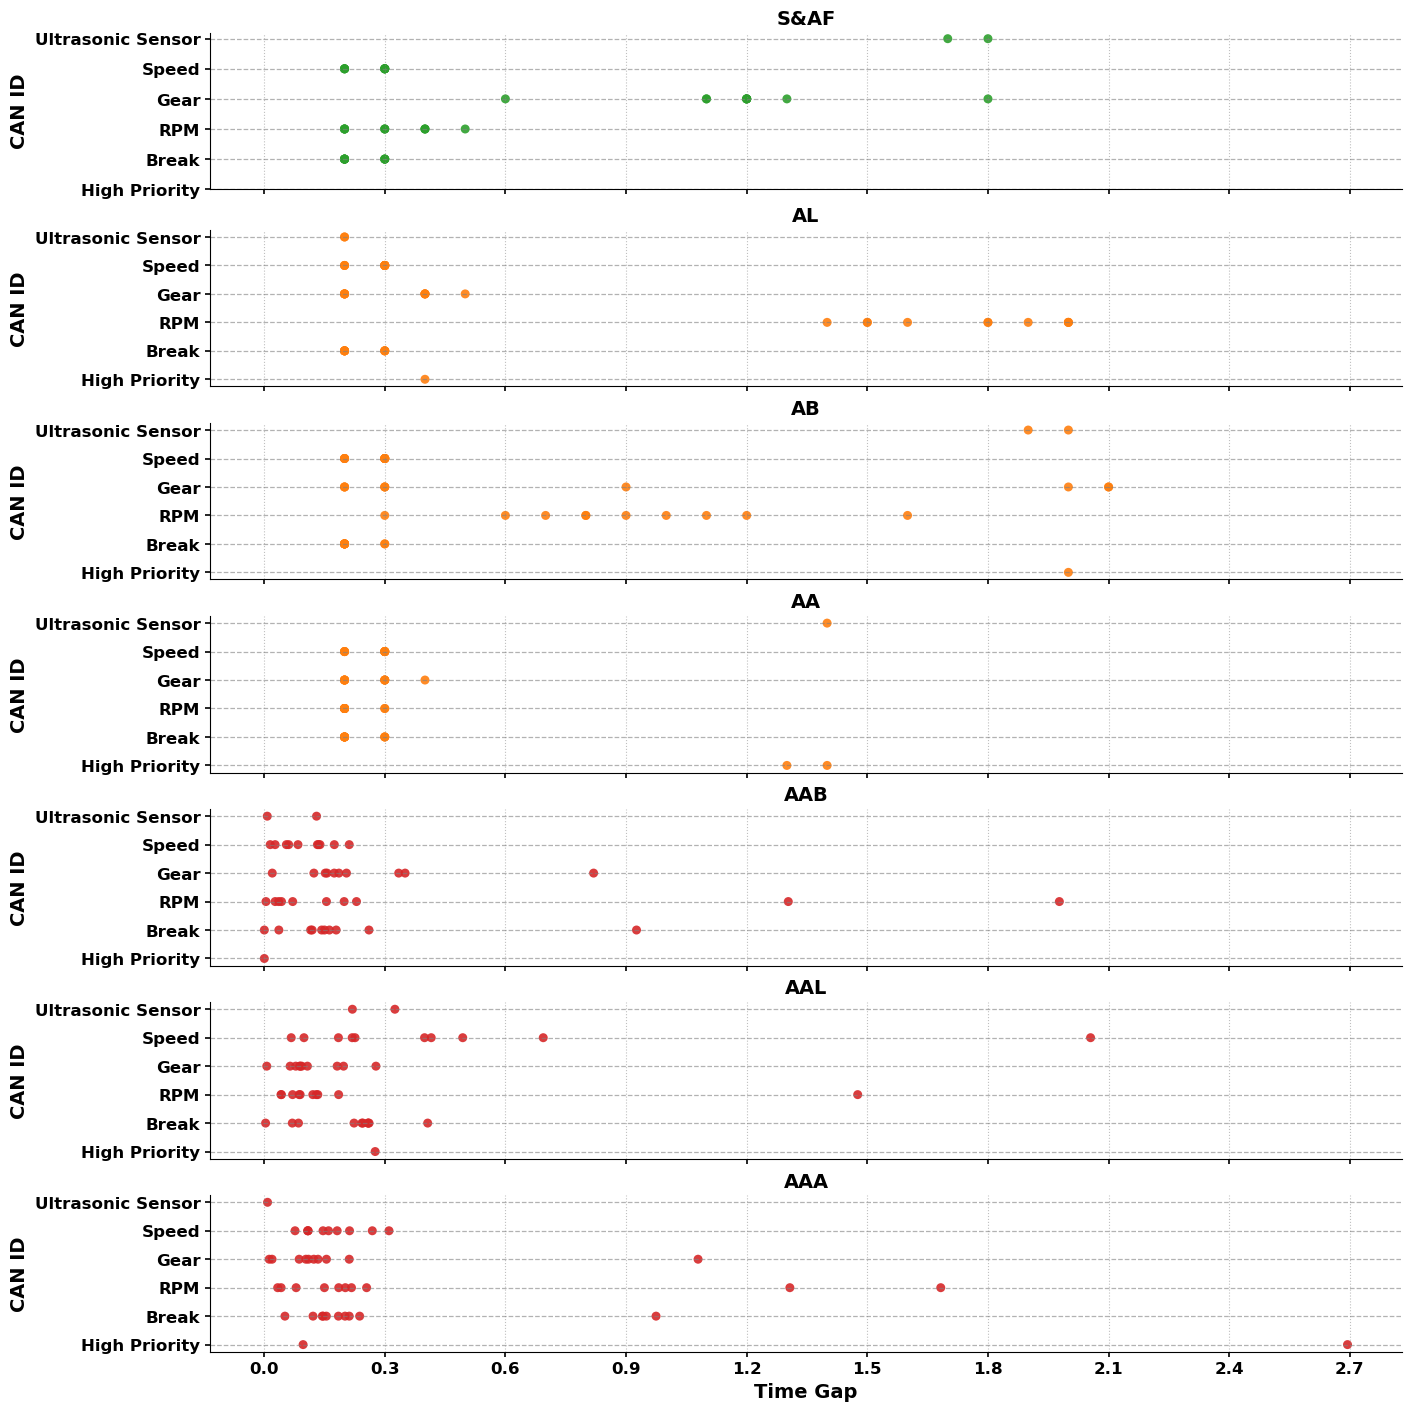

In [321]:
datasets = [
    ("S&AF", Kam_Nor),
    ("AL", Kam_Lane),
    ("AB", Kam_Break),
    ("AA", Kam_Acc),
    ("AAB", Kam_Break_Att),
    ("AAL", Kam_Lane_Att),
    ("AAA", Kam_Acc_Att),
]

plot_can_rowwise_presentable(
    datasets,
    x_col='Time_Delta',
    id_col='CAN_ID',
    id_order=['0018', '0220', '0316', '043F', '0440', '0510'],
    window=100,
    marker_size=42
)

In [178]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_can_rowwise_presentable(
    datasets,
    x_col='Time_Delta',
    id_col='CAN_ID',
    id_order=None,
    window=100,
    figsize=(14, 12),
    marker_size=36,
    alpha=0.80,
    sharex=True,
    sort_by_time=True
):
    if id_order is None:
        id_order = ['0220', '0316', '043F', '0440', '0510']

    id_to_y = {cid: i for i, cid in enumerate(id_order)}
    n_panels = len(datasets)

    colors = [
        'tab:green',
        'tab:orange',
        'tab:orange',
        'tab:orange',
        'tab:red',
        'tab:red',
        'tab:red'
    ]

    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=figsize,
        sharex=sharex,
        constrained_layout=True
    )

    if n_panels == 1:
        axes = [axes]

    fig.patch.set_facecolor('white')

    for i, (ax, (label, df)) in enumerate(zip(axes, datasets)):
        d = df.copy().reset_index(drop=True)

        if d.empty:
            ax.set_title(label, loc='center', fontsize=12, fontweight='bold')
            ax.set_yticks(range(len(id_order)))
            ax.set_yticklabels(id_order)
            ax.set_ylabel("CAN ID")
            ax.grid(True, axis='y', linestyle='--', alpha=0.25)
            continue

        if x_col not in d.columns:
            raise KeyError(f"Column '{x_col}' not found in dataset '{label}'")

        d = d.iloc[:window].copy()

        try:
            d[id_col] = d[id_col].astype(str).str.upper().str.zfill(4)
        except Exception:
            d[id_col] = d[id_col].apply(lambda x: str(x).upper().zfill(4))

        if not d[id_col].isin(id_order).any():
            try:
                d[id_col] = d[id_col].apply(lambda x: format(int(x), '04X'))
            except Exception:
                pass

        d = d[d[id_col].isin(id_order)].copy()

        if sort_by_time:
            d = d.sort_values(by=x_col).reset_index(drop=True)

        d['y'] = d[id_col].map(id_to_y)

        # scatter only: much cleaner for categorical CAN IDs
        ax.scatter(
            d[x_col],
            d['y'],
            s=marker_size,
            alpha=alpha,
            color=colors[i % len(colors)],
            edgecolors='none'
        )

        ax.set_title(label, loc='center', fontsize=12, fontweight='bold')
        ax.set_yticks(range(len(id_order)))
        ax.set_yticklabels(id_order)
        ax.set_ylabel("CAN ID")
        ax.grid(True, axis='y', linestyle='--', alpha=0.25)
        ax.grid(True, axis='x', linestyle=':', alpha=0.18)
        ax.set_facecolor('white')

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        if "Attack" in label:
            ax.axhspan(-0.5, len(id_order) - 0.5, color='#fff5f5', zorder=0)

    axes[-1].set_xlabel("Time Delta")
    fig.suptitle("CAN ID Distribution Across Driving and Attack Conditions",
                 fontsize=16, fontweight='bold')
    plt.show()

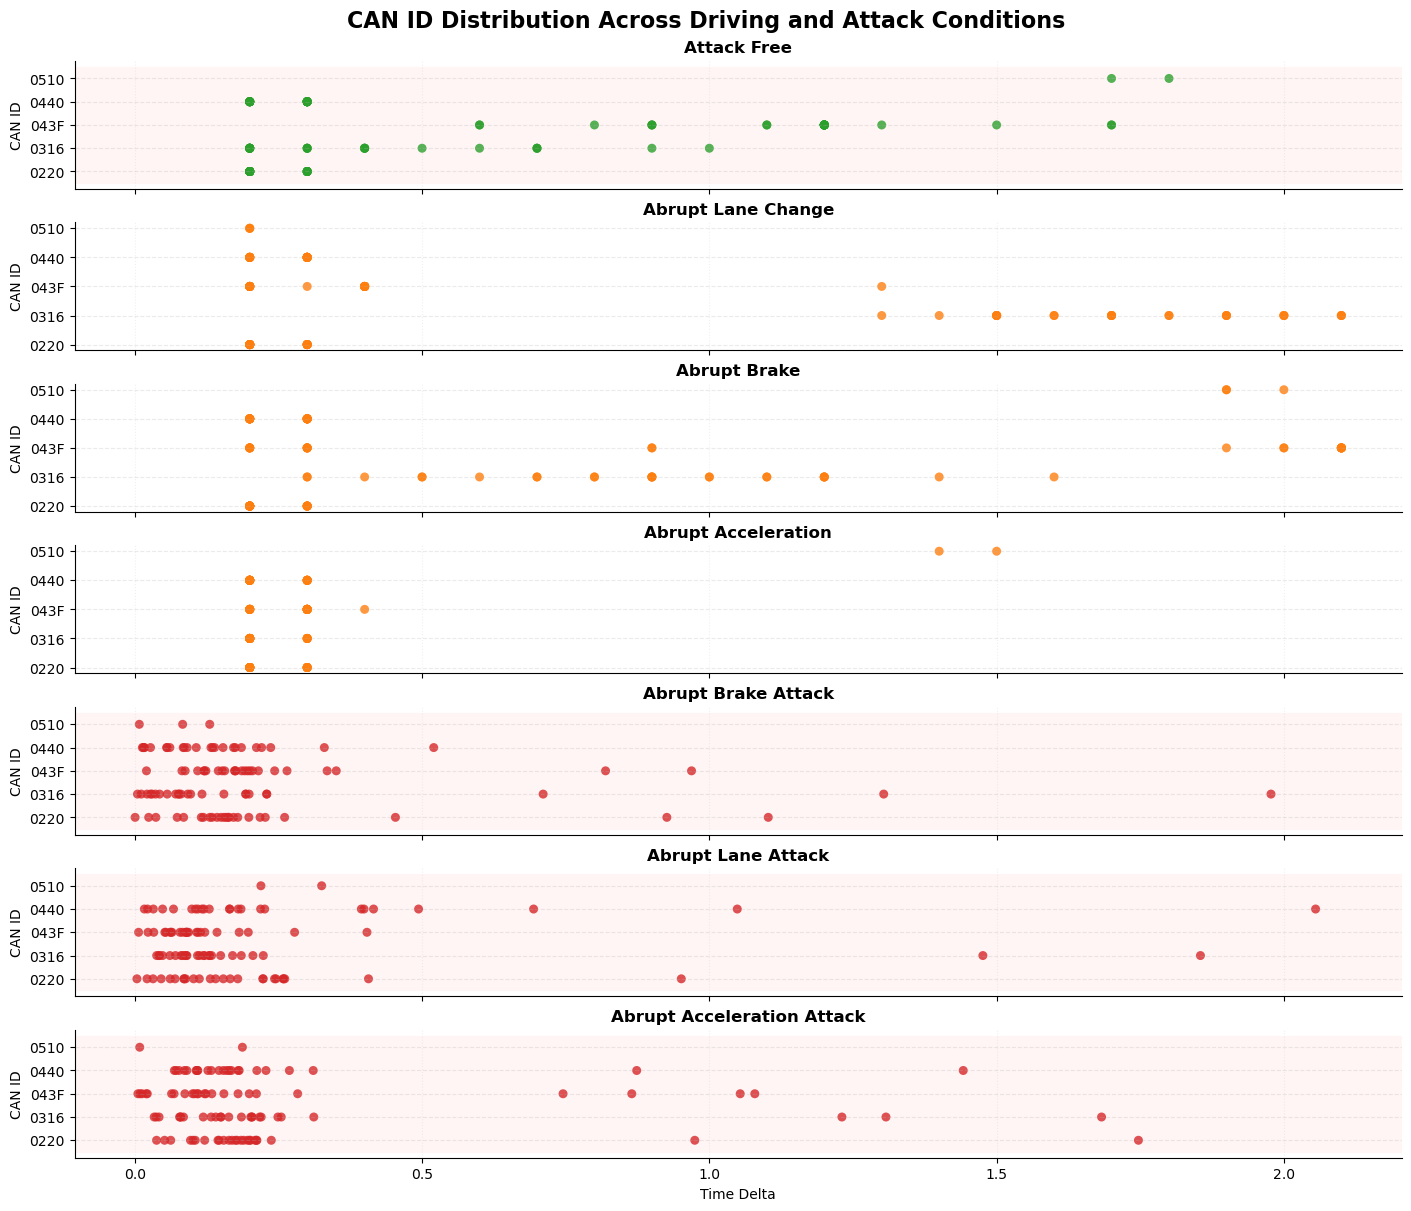

In [179]:
datasets = [
    ("Attack Free", Kam_Nor),
    ("Abrupt Lane Change", Kam_Lane),
    ("Abrupt Brake", Kam_Break),
    ("Abrupt Acceleration", Kam_Acc),
    ("Abrupt Brake Attack", Kam_Break_Att),
    ("Abrupt Lane Attack", Kam_Lane_Att),
    ("Abrupt Acceleration Attack", Kam_Acc_Att),
]

plot_can_rowwise_presentable(
    datasets,
    x_col='Time_Delta',
    id_col='CAN_ID',
    id_order=['0220', '0316', '043F', '0440', '0510'],
    window=100,
    marker_size=42
)